# 02_Diffraction_Sorting_SSA_v5_B Radial Diffraction Presence Scorer

5a - the hybrid scorer is dominatred by:
- overall brightness
- detector noise
- FEP scattering
- Hotspots

this version focuses on:
- radial variance
- ring contrast
- structured intensity vs radius

similar to manual identification in DAWN 

In [1]:
# Cell 1 : imports
import os
import numpy as np
import h5py
import fabio
import matplotlib.pyplot as plt
from tqdm import tqdm


In [2]:
# Cell 2: inputs
# ===== USER INPUTS =====

data_folder = "D:/I11 Beamtime July 25 - LHIST/sorting_v2_test"

# number of radial bins
n_radial_bins = 500
 

In [3]:
# Cell 3: Correct Pixium Loader - off of entry/data/data
# ===== USER INPUTS =====

def load_detector_frame(filepath):
    """
    Load 2D Pixium detector frame from I11 NeXus/HDF5.
    Returns a 2D numpy array.
    """
    ext = filepath.lower()

    try:
        if ext.endswith((".hdf", ".h5", ".nxs")):
            with h5py.File(filepath, "r") as f:
                data = f["entry/data/data"][()]
                return data[0] if data.ndim == 3 else data

        elif ext.endswith((".tif", ".tiff", ".cbf")):
            return fabio.open(filepath).data

        else:
            raise ValueError("Unsupported file type")

    except Exception as e:
        print(f"Failed to load {filepath}: {e}")
        return None



In [5]:
# Cell 4 - Radial Diffraction Score 

# Why this works:
#Background → smooth radial profile → low std
#Diffraction → peaks in I(r) → high std
#Insensitive to total brightness
#This is physically aligned with powder diffraction.

def radial_diffraction_score(img, n_bins=500):
    """
    Computes a radial diffraction presence score.
    High score = strong ring-like structure.
    """

    if img is None:
        return 0.0, None

    img = np.nan_to_num(img, nan=0.0)
    img[img < 0] = 0

    ny, nx = img.shape
    cy, cx = ny // 2, nx // 2

    y, x = np.indices(img.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2)

    r_flat = r.flatten()
    i_flat = img.flatten()

    r_bins = np.linspace(0, r_flat.max(), n_bins + 1)
    bin_indices = np.digitize(r_flat, r_bins)

    radial_mean = np.zeros(n_bins)
    radial_std = np.zeros(n_bins)

    for i in range(1, n_bins + 1):
        mask = bin_indices == i
        if np.any(mask):
            radial_mean[i-1] = np.mean(i_flat[mask])
            radial_std[i-1] = np.std(i_flat[mask])

    # Diffraction presence metric:
    # ringiness = variance of radial mean + contrast
    score = np.std(radial_mean) * np.mean(radial_std)

    return score, radial_mean


Processing 31 files


100%|██████████████████████████████████████████████████████████████████████████████████| 31/31 [02:33<00:00,  4.96s/it]


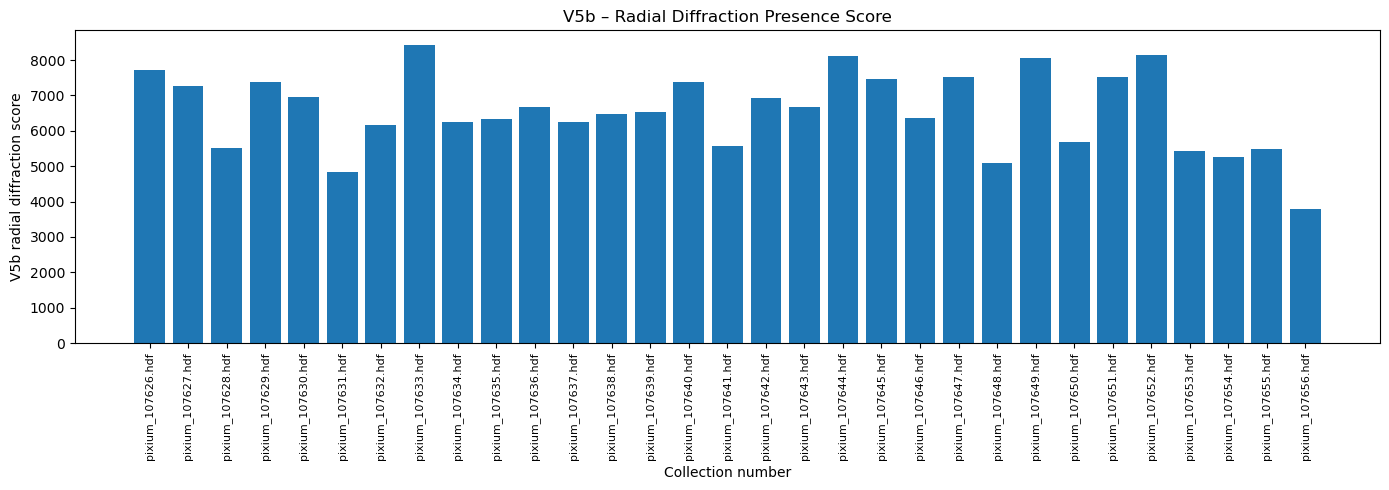

In [8]:
# Cell 5 - Run on the Folder and Plot 
import glob

files = sorted(glob.glob(os.path.join(data_folder, "*.hdf")))
scores = []

print(f"Processing {len(files)} files")

for f in tqdm(files):
    img = load_detector_frame(f)
    score, _ = radial_diffraction_score(img, n_bins=n_radial_bins)
    scores.append(score)
    
file_labels = [os.path.basename(f) for f in files]

# ---- Plot ----
plt.figure(figsize=(14,5))
plt.bar(range(len(scores)), scores)
plt.xlabel("Collection number")
plt.ylabel("V5b radial diffraction score")
plt.title("V5b – Radial Diffraction Presence Score")
plt.xticks(range(len(file_labels)), file_labels, rotation=90, fontsize=8)
plt.tight_layout()
plt.show()
